Saving 09-RTSOCS - 2022.10.18-11.57.53.csv to 09-RTSOCS - 2022.10.18-11.57.53 (1).csv
✅ File '09-RTSOCS - 2022.10.18-11.57.53 (1).csv' uploaded successfully!
Columns: Index(['insole', 'foot', 'timestamp', 'seq', 'acx', 'acy', 'acz', 'gyrx',
       'gyry', 'gyrz', 'p_toe_1_f', 'p_toe_1_b', 'p_toe_3', 'p_toe_5',
       'p_arc_i', 'p_arc_o', 'p_heel_i', 'p_heel_o', 'roll', 'pitch', 'yaw'],
      dtype='object')
Using columns → X: acx, Y: acy, Z: acz
Features and labels ready!
       mean       std       rms       max       min       ptp      skew  \
0  1.077382  0.177776  1.091950  1.525397  0.842909  0.682488  1.318551   
1  1.612429  0.864985  1.829789  3.884294  0.679991  3.204303  1.280342   
2  1.651914  0.830165  1.848781  3.795341  0.827016  2.968324  1.248695   
3  1.767725  0.947014  2.005414  4.165323  0.866480  3.298843  1.189331   
4  1.652861  0.809638  1.840506  3.529010  0.832864  2.696145  0.953459   

       kurt  jerk_mean  jerk_std  freq_mean  freq_max  freq_entropy  la

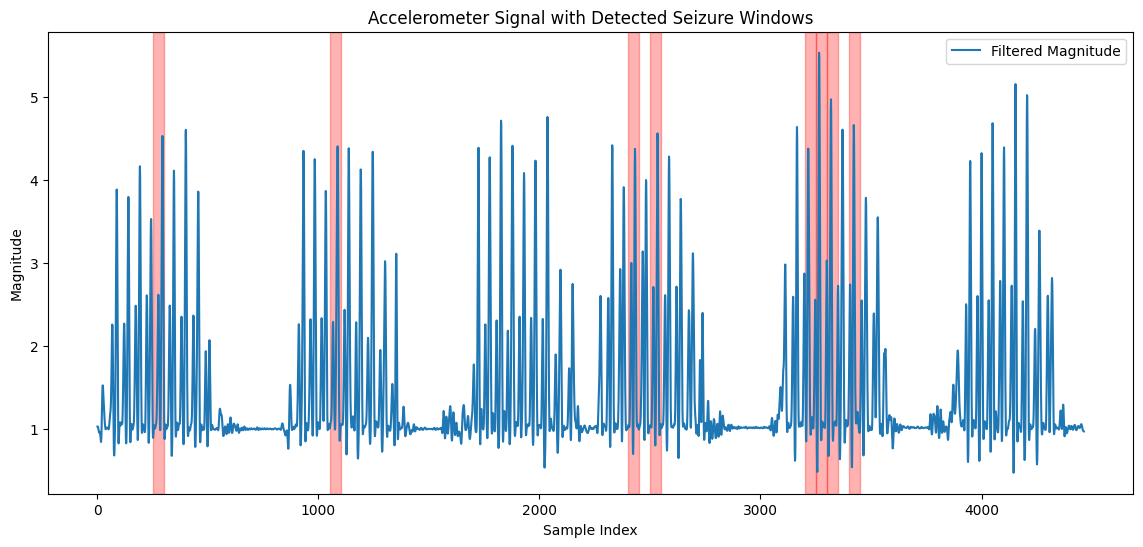

✅ Features and labels saved to 'seizure_features_labels.csv'


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from google.colab import files

# ==============================
# STEP 1: Upload CSV
# ==============================
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
data = pd.read_csv(file_name)
print(f"✅ File '{file_name}' uploaded successfully!")
print("Columns:", data.columns)

# ==============================
# STEP 2: Detect x, y, z columns automatically
# ==============================
possible_names = {
    'x': ['x', 'acc_x', 'accx', 'x-axis', 'x_axis'],
    'y': ['y', 'acc_y', 'accy', 'y-axis', 'y_axis'],
    'z': ['z', 'acc_z', 'accz', 'z-axis', 'z_axis']
}

def find_column(possible_list):
    for name in possible_list:
        for col in data.columns:
            if name.lower() in col.lower():
                return col
    return None

x_col = find_column(possible_names['x'])
y_col = find_column(possible_names['y'])
z_col = find_column(possible_names['z'])

if not all([x_col, y_col, z_col]):
    raise ValueError("❌ Could not detect x, y, z columns automatically. Please check dataset.")

print(f"Using columns → X: {x_col}, Y: {y_col}, Z: {z_col}")

# ==============================
# STEP 3: Preprocessing & Magnitude
# ==============================
data['magnitude'] = np.sqrt(data[x_col]**2 + data[y_col]**2 + data[z_col]**2)

def butter_lowpass_filter(signal, cutoff=5, fs=50, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low')
    return filtfilt(b, a, signal)

fs = 50
data['filtered_mag'] = butter_lowpass_filter(data['magnitude'], fs=fs)

# ==============================
# STEP 4: Feature Extraction
# ==============================
window_size = 50  # 1 second at 50 Hz

def extract_features(segment, fs=50):
    features = {}
    # Time-domain features
    features['mean'] = np.mean(segment)
    features['std'] = np.std(segment)
    features['rms'] = np.sqrt(np.mean(segment**2))
    features['max'] = np.max(segment)
    features['min'] = np.min(segment)
    features['ptp'] = np.ptp(segment)
    features['skew'] = pd.Series(segment).skew()
    features['kurt'] = pd.Series(segment).kurt()
    # Jerk (derivative)
    jerk = np.diff(segment)
    features['jerk_mean'] = np.mean(jerk)
    features['jerk_std'] = np.std(jerk)
    # Frequency-domain features
    f, Pxx = welch(segment, fs=fs, nperseg=len(segment))
    features['freq_mean'] = np.mean(Pxx)
    features['freq_max'] = np.max(Pxx)
    features['freq_entropy'] = -np.sum(Pxx*np.log(Pxx+1e-12))
    return features

segments = []
for start in range(0, len(data)-window_size, window_size):
    seg = data['filtered_mag'].iloc[start:start+window_size].values
    feats = extract_features(seg, fs)
    segments.append(feats)

features_df = pd.DataFrame(segments)

# ==============================
# STEP 5: Labels (Simulated)
# ==============================
# Label top 10% magnitude windows as seizure for demo purposes
features_df['label'] = 0
mag_means = features_df['mean']
threshold = np.percentile(mag_means, 90)
features_df.loc[mag_means > threshold, 'label'] = 1

print("Features and labels ready!")
print(features_df.head())

# ==============================
# STEP 6: ML Model (Random Forest)
# ==============================
X = features_df.drop('label', axis=1)
y = features_df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred_test = clf.predict(X_test)
y_pred_full = clf.predict(X)  # Full dataset predictions for visualization

# ==============================
# STEP 7: Evaluation
# ==============================
acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test)
rec = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)
cm = confusion_matrix(y_test, y_pred_test)

print("\n📊 Model Evaluation:")
print(f"Accuracy: {acc:.2f}, Precision: {prec:.2f}, Recall: {rec:.2f}, F1 Score: {f1:.2f}")
print("Confusion Matrix:\n", cm)

# ==============================
# STEP 8: Visualization
# ==============================
plt.figure(figsize=(14,6))
plt.plot(data['filtered_mag'], label='Filtered Magnitude')
plt.title("Accelerometer Signal with Detected Seizure Windows")
plt.xlabel("Sample Index")
plt.ylabel("Magnitude")

# Highlight predicted seizure windows
window_idx = 0
for start in range(0, len(data)-window_size, window_size):
    if y_pred_full[window_idx] == 1:
        plt.axvspan(start, start+window_size, color='red', alpha=0.3)
    window_idx += 1

plt.legend()
plt.show()

# ==============================
# STEP 9: Save Results
# ==============================
features_df.to_csv("seizure_features_labels.csv", index=False)
print("✅ Features and labels saved to 'seizure_features_labels.csv'")